# HL HIP-3 oil volume — WTI + Brent

Daily USD notional volume on the two oil builder-perps on the `xyz` HIP-3 dex:
- **`xyz:CL`** — WTI crude (inception 2026-01-06)
- **`xyz:BRENTOIL`** — Brent crude (inception 2026-03-04)

Source: CSVs at `./` (alongside this notebook), pulled from `POST https://api.hyperliquid.xyz/info {"type":"candleSnapshot",...}`.

USD notional approximated as `volume × VWAP_HLC3` where `VWAP_HLC3 = (H + L + C) / 3` (standard TA typical-price proxy).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

DATA_DIR = '.'   # same folder as the notebook

wti   = pd.read_csv(f'{DATA_DIR}/xyz_CL.csv',       parse_dates=['date']).set_index('date')
brent = pd.read_csv(f'{DATA_DIR}/xyz_BRENTOIL.csv', parse_dates=['date']).set_index('date')

print(f'WTI:   {len(wti):>4} rows, {wti.index.min().date()} → {wti.index.max().date()}')
print(f'Brent: {len(brent):>4} rows, {brent.index.min().date()} → {brent.index.max().date()}')
wti.tail(3)

WTI:    164 rows, 2026-01-06 → 2026-06-18
Brent:  107 rows, 2026-03-04 → 2026-06-18


,open,high,low,close,volume,num_trades,vwap_hlc3,usd_volume
date,,,,,,,,
2026-06-16,80.175,80.175,74.729,75.894,3516166.710,100867,76.9327,2.705081e+08
2026-06-17,75.890,78.931,74.089,75.316,4108115.709,120988,76.1120,3.126769e+08
2026-06-18,75.310,75.414,74.600,74.917,380506.595,14163,74.9770,2.852924e+07


In [2]:
# Align on a common date index. Brent rows that don't exist are left as NaN → plotted as 0.
vol = pd.DataFrame({
    'WTI':   wti['usd_volume'],
    'Brent': brent['usd_volume'],
}).reindex(wti.index.union(brent.index)).fillna(0)

print(f'date range: {vol.index.min().date()} → {vol.index.max().date()}  ({len(vol)} days)')
print(f'total notional: WTI \\$ {vol["WTI"].sum()/1e9:.2f} B   Brent \\$ {vol["Brent"].sum()/1e9:.2f} B   combined \\$ {(vol.sum().sum())/1e9:.2f} B')
vol.tail(7)

date range: 2026-01-06 → 2026-06-18  (164 days)
total notional: WTI \$ 60.62 B   Brent \$ 27.75 B   combined \$ 88.36 B


,WTI,Brent
date,,
2026-06-12,5.495282e+08,2.753521e+08
2026-06-13,6.843633e+07,4.511122e+07
2026-06-14,2.470620e+08,1.859805e+08
2026-06-15,2.171114e+08,9.403438e+07
2026-06-16,2.705081e+08,1.137388e+08
2026-06-17,3.126769e+08,1.677293e+08
2026-06-18,2.852924e+07,1.277449e+07


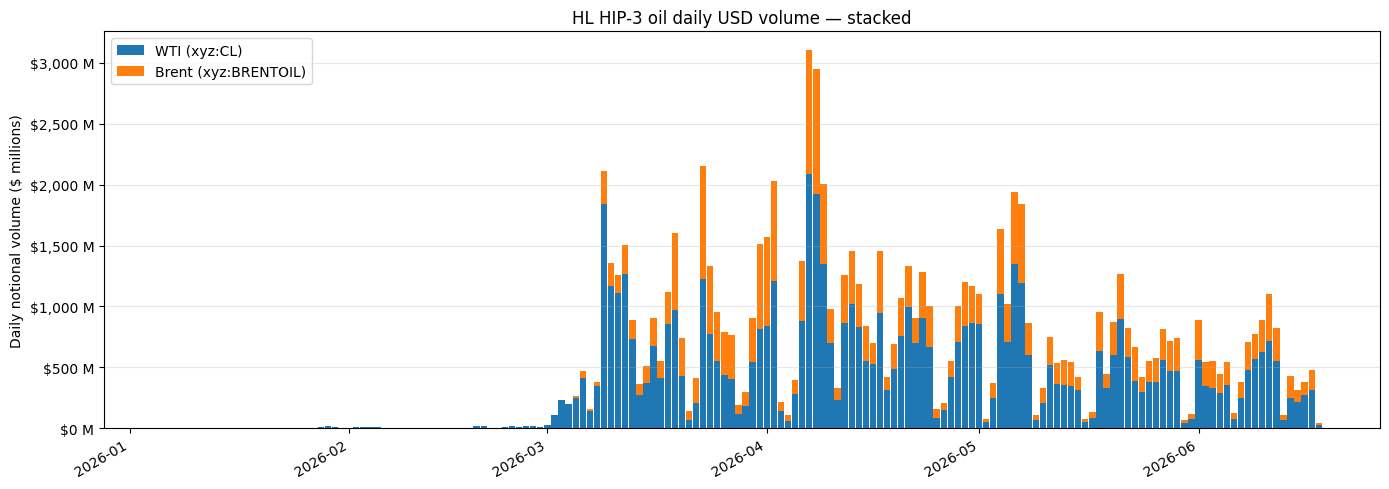

In [3]:
# Stacked bar chart
fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(vol.index, vol['WTI']/1e6,                   width=0.9, label='WTI (xyz:CL)',          color='#1f77b4')
ax.bar(vol.index, vol['Brent']/1e6, bottom=vol['WTI']/1e6, width=0.9, label='Brent (xyz:BRENTOIL)', color='#ff7f0e')

ax.set_ylabel('Daily notional volume (\\$ millions)')
ax.set_title('HL HIP-3 oil daily USD volume — stacked')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'\\${v:,.0f} M'))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

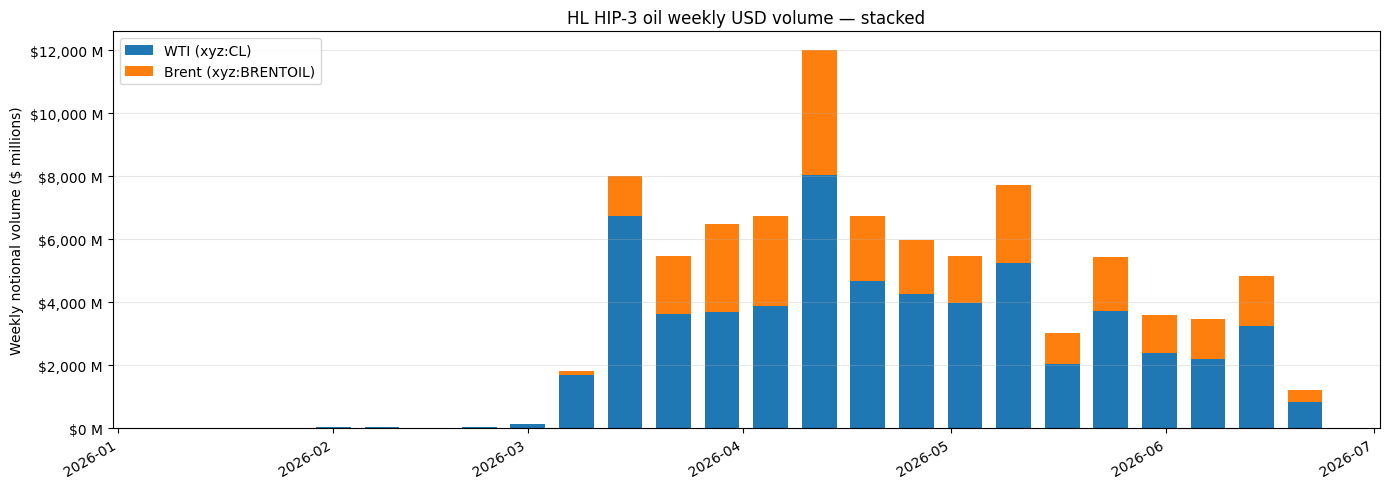

In [4]:
# Optional: weekly aggregate — easier read for the full ~6-month period
weekly = vol.resample('W').sum()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(weekly.index, weekly['WTI']/1e6,                       width=5, label='WTI (xyz:CL)',          color='#1f77b4')
ax.bar(weekly.index, weekly['Brent']/1e6, bottom=weekly['WTI']/1e6, width=5, label='Brent (xyz:BRENTOIL)', color='#ff7f0e')
ax.set_ylabel('Weekly notional volume (\\$ millions)')
ax.set_title('HL HIP-3 oil weekly USD volume — stacked')
ax.legend(loc='upper left')
ax.grid(axis='y', alpha=0.3)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f'\\${v:,.0f} M'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()